In [64]:
#Import the necessary model
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [65]:
#Creating the data for the logic gates
X_and = np.array([
    [1, 0, 0],   # x0, x1, x2
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]])
y_and = np.array([0,0,0,1])

X_or = np.array([
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]])
y_or = np.array([0,1,1,1])

X_not = np.array([
    [1,0],
    [1,1]])
y_not = np.array([1,0])

In [66]:
#Activation (step) function
def step_func(x):
  if x >= 0:
    return 1
  return 0

In [67]:
# Function to do the forward pass and weight update rule
def train_or_perceptron(X, y, weights, title, filename,learning_rate=0.5, epochs=10):
  for epoch in range(epochs):
    miss_class = 0
    print("Epoch:", epoch)
    for i in range(len(X)):
      x = X[i]
      y_pred = step_func(np.dot(weights, x))
      error = y[i] - y_pred
      weights = weights + learning_rate * error * x
      print(weights)
      if error != 0:
        miss_class += 1
    current_filename = f"{filename}_Epoch_{epoch+1}.eps"
    plot_decision_boundary(X, y, weights, title,current_filename)
    if miss_class == 0:
      break
  return weights

In [75]:
def plot_decision_boundary(X, y, weights, title, filename):

    plt.figure(figsize=(8, 6))

    #NOT Gate
    if X.shape[1] == 2:

        plt.scatter(X[y == 0, 1],np.zeros(np.sum(y == 0)),color='red',marker='o',s=100,label='Class 0')

        plt.scatter(X[y == 1, 1],np.zeros(np.sum(y == 1)),color='blue',marker='^',s=100,label='Class 1')

        if weights[1] != 0:
            boundary = -weights[0] / weights[1]

            plt.axvline(boundary,color='green',linewidth=2,linestyle='--',label='Decision Boundary')

        plt.xlabel("Input", fontweight='bold')
        plt.yticks([])

    #AND / OR
    elif X.shape[1] == 3:

        plt.scatter(X[y == 0, 1],X[y == 0, 2],color='red',marker='o',s=100,label='Class 0')

        plt.scatter(X[y == 1, 1],X[y == 1, 2],color='blue',marker='^',s=100,label='Class 1')

        if weights[2] != 0:

            x1 = np.linspace(-0.5, 1.5, 100)

            x2 = -(weights[0] + weights[1] * x1) / weights[2]

            plt.plot(x1,x2,color='green',linewidth=2,label='Decision Boundary')

        plt.xlim(-0.5, 1.5)
        plt.ylim(-0.5, 1.5)

        plt.xlabel("x₁", fontweight='bold')
        plt.ylabel("x₂", fontweight='bold')

    else:
        raise ValueError("This function supports only NOT (1 input) or 2-input logic gates.")

    plt.title(title, fontweight='bold')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    plt.savefig(filename,dpi=600,format="eps",bbox_inches="tight")

    plt.show()

Epoch: 0
[-0.5  0.   0. ]
[-0.5  0.   0. ]
[-0.5  0.   0. ]
[0.  0.5 0.5]


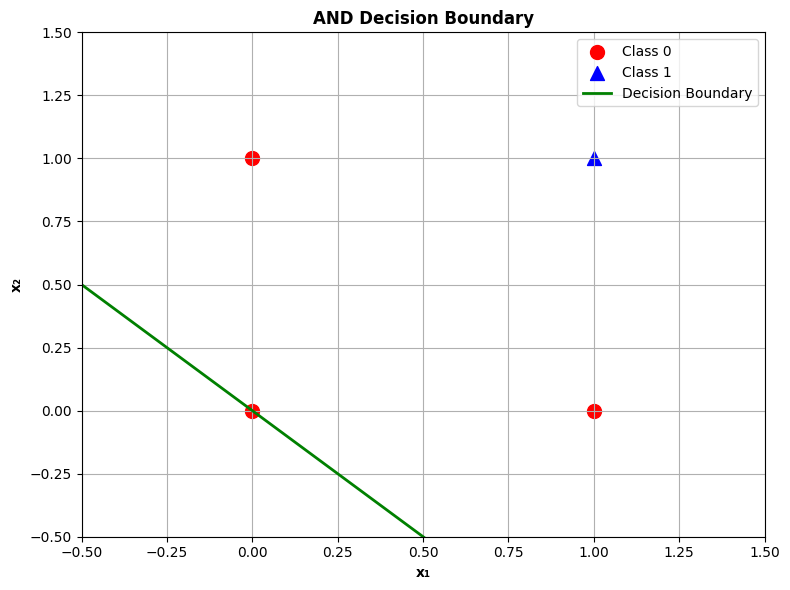

Epoch: 1
[-0.5  0.5  0.5]
[-1.   0.5  0. ]
[-1.   0.5  0. ]
[-0.5  1.   0.5]


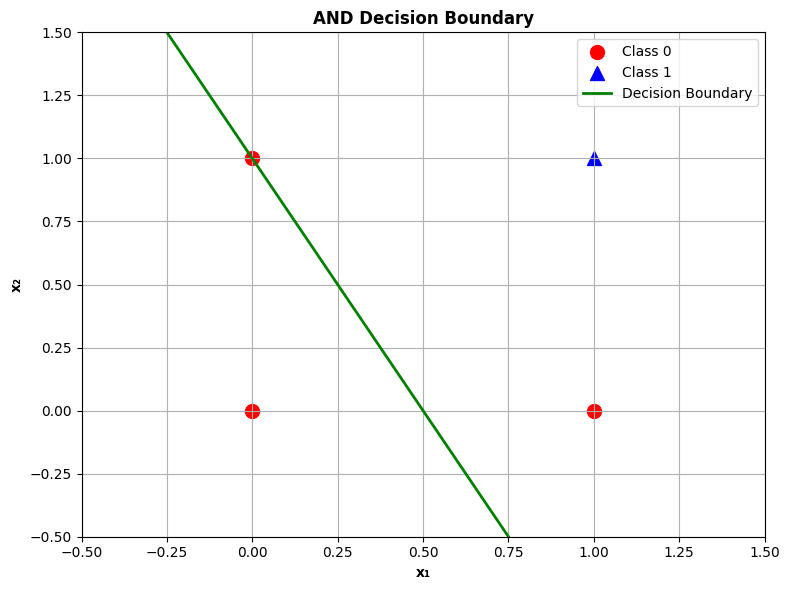

Epoch: 2
[-0.5  1.   0.5]
[-1.  1.  0.]
[-1.5  0.5  0. ]
[-1.   1.   0.5]


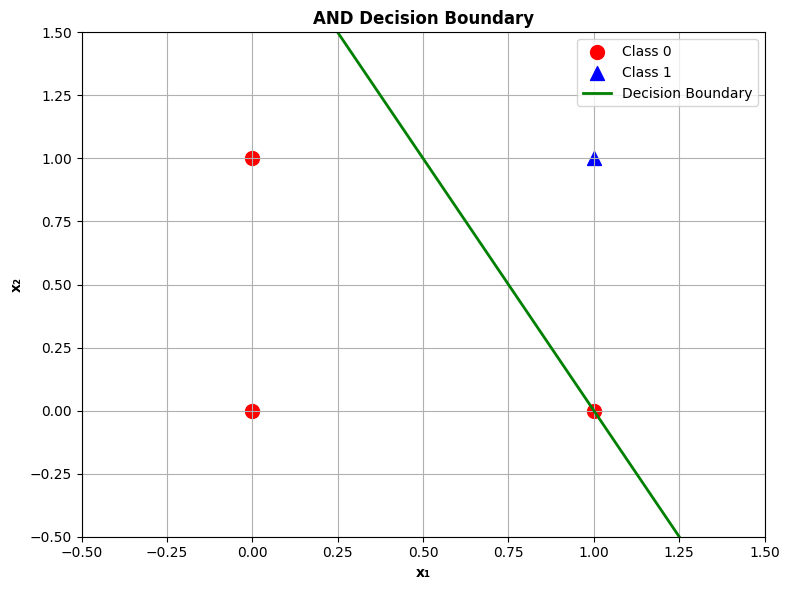

Epoch: 3
[-1.   1.   0.5]
[-1.   1.   0.5]
[-1.5  0.5  0.5]
[-1.  1.  1.]


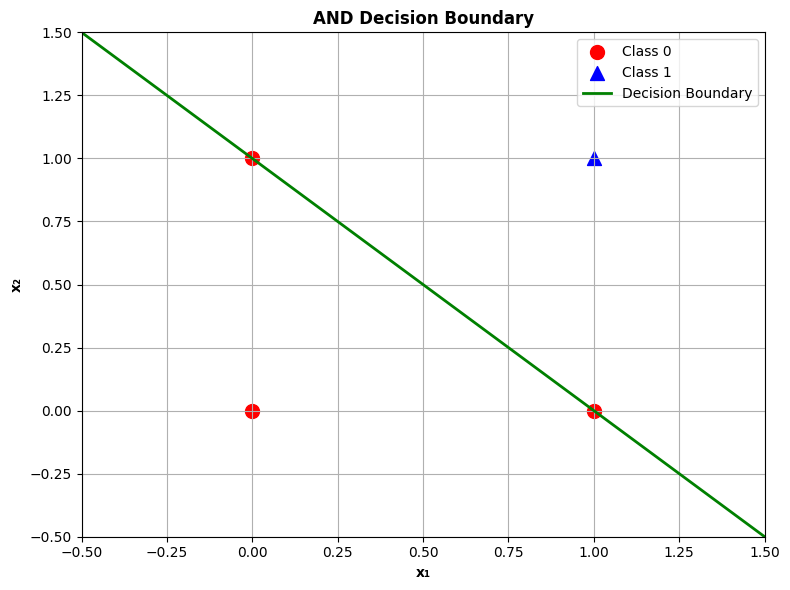

Epoch: 4
[-1.  1.  1.]
[-1.5  1.   0.5]
[-1.5  1.   0.5]
[-1.5  1.   0.5]


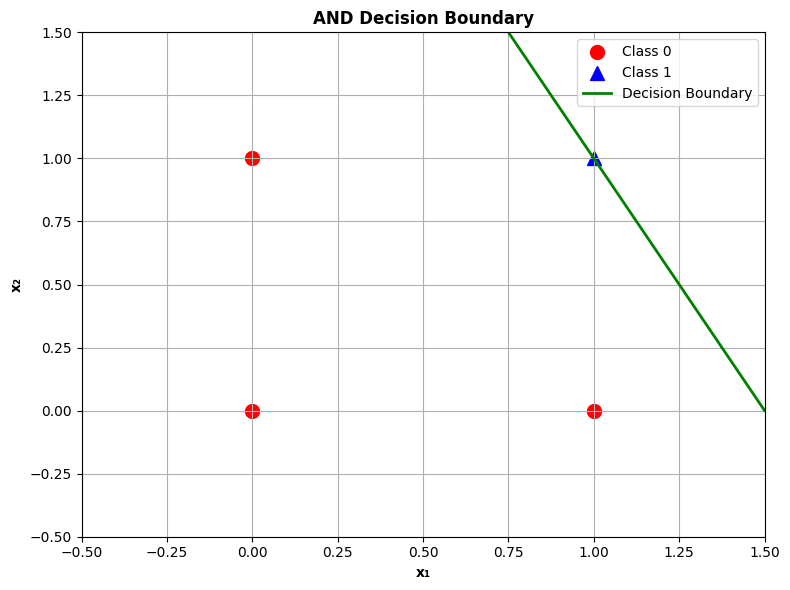

Epoch: 5
[-1.5  1.   0.5]
[-1.5  1.   0.5]
[-1.5  1.   0.5]
[-1.5  1.   0.5]


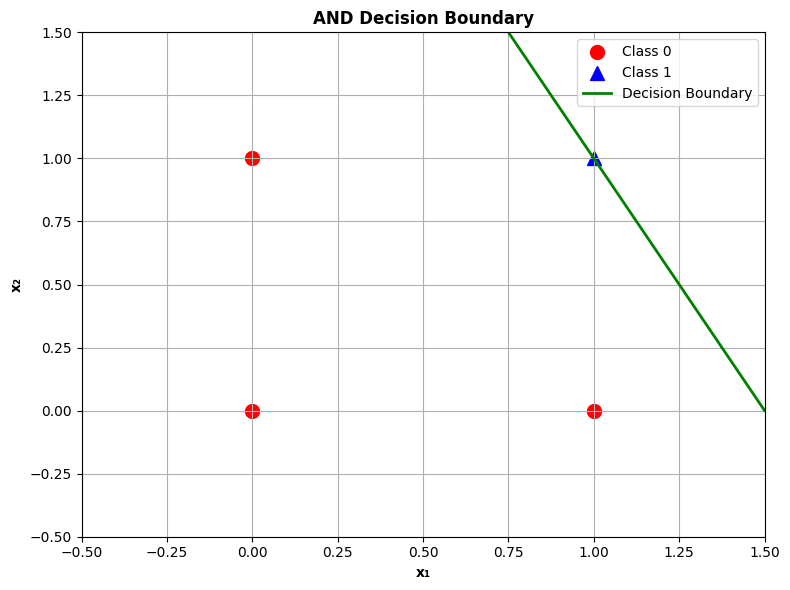

[-1.5  1.   0.5]


In [69]:
#Initilize the graph and train the model for the AND gate
weights = np.zeros(3,)
title_and = "AND Decision Boundary"
filename_and = 'AND'
we = train_or_perceptron(X_and, y_and, weights,title_and,filename_and)
print(we)

In [70]:
#To validate and plot the AND gate
correct = 0
for i in range(len(X_and)):
    x = X_and[i]
    y_pred = step_func(np.dot(we, x))

    if y_pred == y_and[i]:
        correct += 1
print("Accuracy:", correct, "/", len(X_and))

Accuracy: 4 / 4


Epoch: 0
[-0.5  0.   0. ]
[0.  0.  0.5]
[0.  0.  0.5]
[0.  0.  0.5]


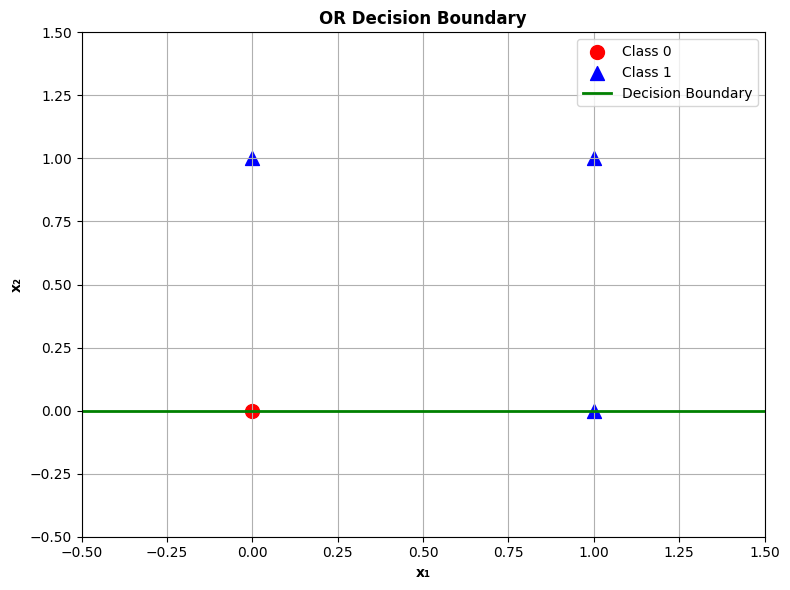

Epoch: 1
[-0.5  0.   0.5]
[-0.5  0.   0.5]
[0.  0.5 0.5]
[0.  0.5 0.5]


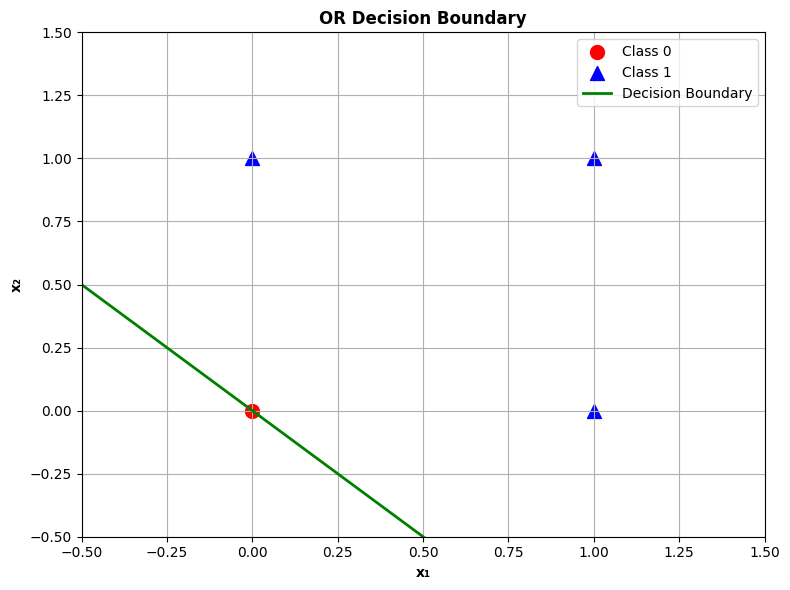

Epoch: 2
[-0.5  0.5  0.5]
[-0.5  0.5  0.5]
[-0.5  0.5  0.5]
[-0.5  0.5  0.5]


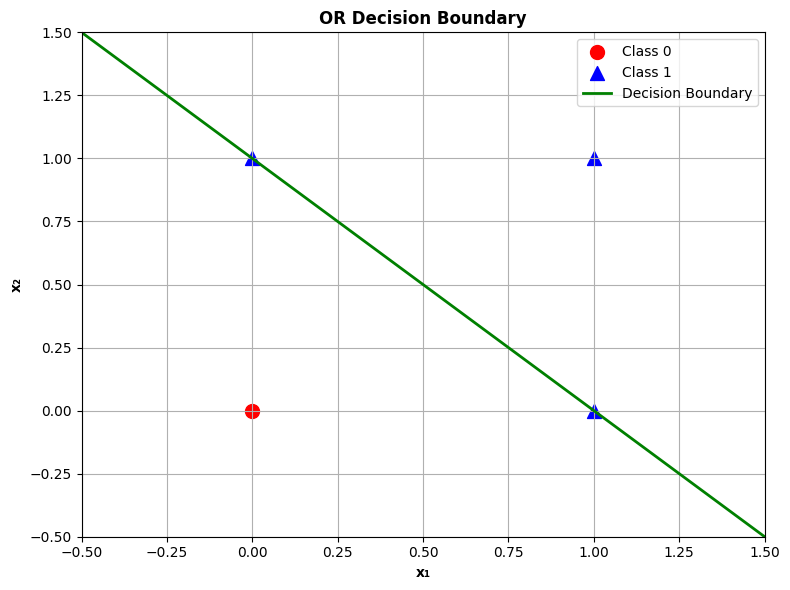

Epoch: 3
[-0.5  0.5  0.5]
[-0.5  0.5  0.5]
[-0.5  0.5  0.5]
[-0.5  0.5  0.5]


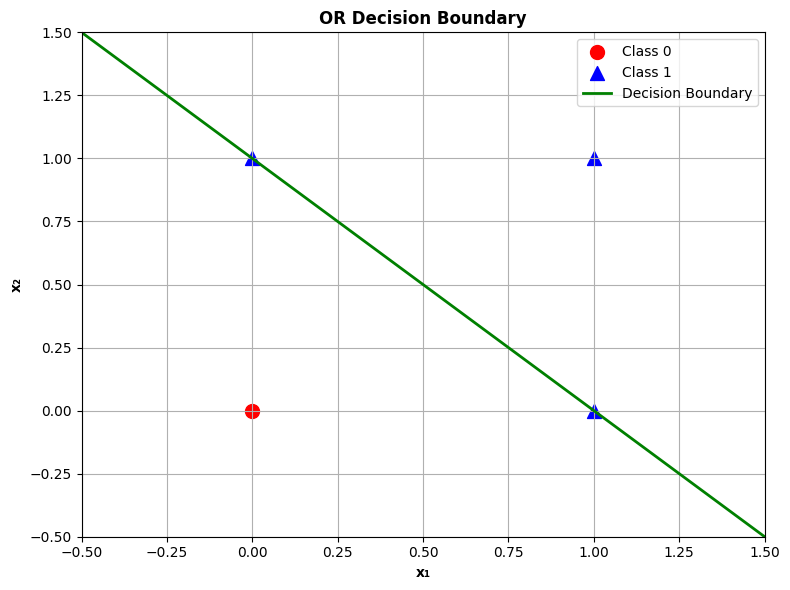

[-0.5  0.5  0.5]


In [71]:
#Initilize the graph and train the model for the OR gate
weights_or = np.zeros(3,)
title_or = "OR Decision Boundary"
filename_or = 'OR'
w_or = train_or_perceptron(X_or, y_or, weights_or,title_or,filename_or)
print(w_or)

In [72]:
#To validate and plot the OR gate
orrect = 0
for i in range(len(X_or)):
    x = X_or[i]
    y_pred = step_func(np.dot(w_or, x))
    if y_pred == y_or[i]:
        orrect += 1

print("Accuracy:", orrect, "/", len(X_or))

Accuracy: 4 / 4


Epoch: 0
[0. 0.]
[-0.5 -0.5]


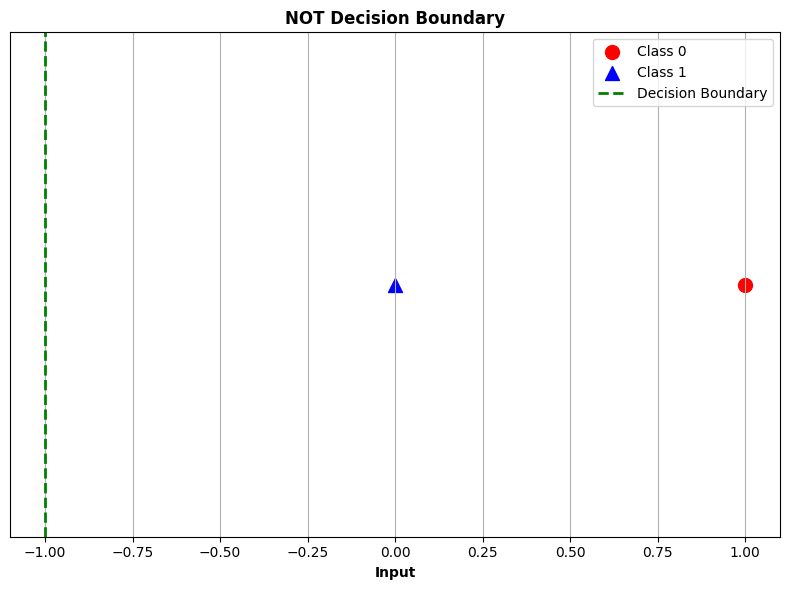

Epoch: 1
[ 0.  -0.5]
[ 0.  -0.5]


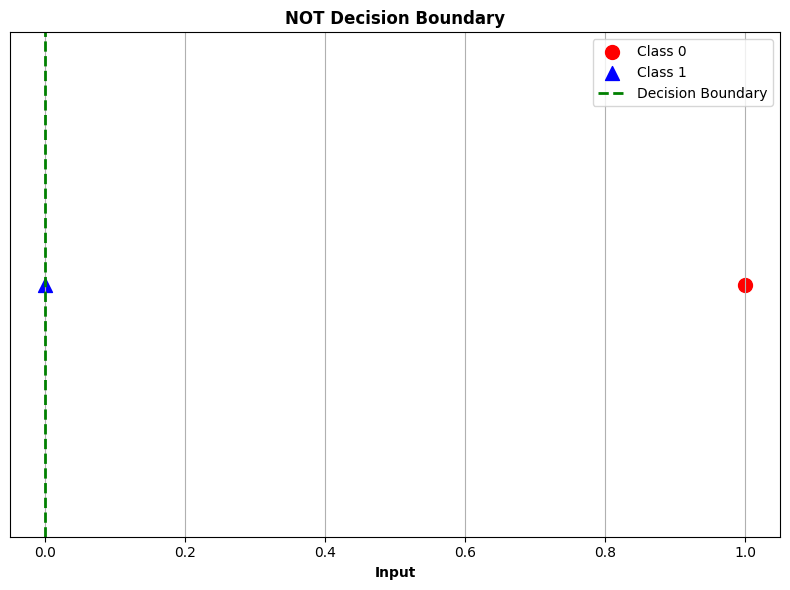

Epoch: 2
[ 0.  -0.5]
[ 0.  -0.5]


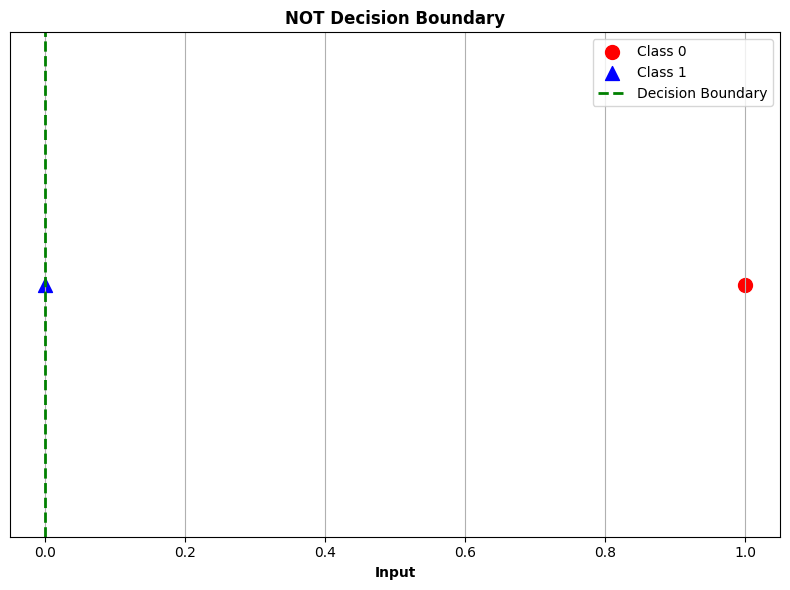

[ 0.  -0.5]


In [73]:
#Initilize the graph and train the model for the NOT gate
weights_not = np.zeros(2,)
title_not = "NOT Decision Boundary"
filename_not = 'NOT'
w_not = train_or_perceptron(X_not, y_not, weights_not,title_not,filename_not)
print(w_not)

In [74]:
#TO validate the NOT gate
correct_not = 0
for i in range(len(X_not)):
    x = X_not[i]
    y_pred = step_func(np.dot(w_not, x))
    print(y_pred)
    if y_pred == y_not[i]:
        correct_not += 1
print("Accuracy:", correct_not, "/", len(X_not))

1
0
Accuracy: 2 / 2
